# 01 – Exploratory Data Analysis

**Project:** Area Feasibility Scoring Model  
**Goal:** Understand the shape, quality and distribution of property price data before any feature engineering or modelling.

---
### Contents
1. Setup & Data Loading
2. Dataset Overview
3. Price Distribution Analysis
4. Area-Level Aggregation Preview
5. Affordability Baseline (raw)
6. Geospatial Overview (if coordinates available)
7. Key Takeaways

## 1 · Setup & Data Loading

In [ ]:
import sys, os
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

from data_loader import generate_synthetic_data, aggregate_to_area,load_land_registry

# -------------------------------------------------------------------
# Change this path to your real Land Registry CSV if available.
# We fall back to synthetic data automatically.
# -------------------------------------------------------------------
DATA_PATH   = '../data/pp-complete.csv'   # Land Registry Price Paid
data_input_dir = Path("../data/year_by_year/")
USER_BUDGET = 500_000                     # £ – the user's property budget

chunks = []
try:
    data_input_dir.mkdir(exist_ok=True)
    for file in sorted(data_input_dir.glob("pp-*.csv")):
        tx_df = load_land_registry(file)
        print (f"Processed {file} shape {tx_df.shape}...")
        chunks.append(tx_df)
        del tx_df


    combined_df = pd.concat(chunks, ignore_index=True)
    del chunks
    print(f"Combined DataFrame shape: {combined_df.shape}")
    combined_df.to_csv(DATA_PATH, index=False)
    del combined_df
    print(f"Combined data saved to {DATA_PATH}")
except:
    print("no files found, skipping combination step")

if os.path.exists(DATA_PATH):
    tx_df = load_land_registry(DATA_PATH)
    print(f'Loaded {len(tx_df):,} real transactions')
else:
    print('Real data not found – using synthetic dataset.')
    tx_df = generate_synthetic_data(n_transactions=20_000, n_areas=50)

print(tx_df.shape)
tx_df.head()

Processed ../data/year_by_year/pp-2024.csv shape (918802, 16)...
Processed ../data/year_by_year/pp-2025.csv shape (756578, 16)...
Combined DataFrame shape: (1675380, 16)
Combined data saved to ../data/pp-complete.csv
Loaded 1,675,380 real transactions
(1675380, 16)


,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category_type,record_status
1,{2ACACE8D-176B-295E-E063-4804A8C0B0EB},320000.0,2024-03-20,NR9 5FP,D,Y,F,24,NaN,DUSTY MILLER DRIVE,EASTON,NORWICH,SOUTH NORFOLK,NORFOLK,A,A
2,{2ACACE8D-176C-295E-E063-4804A8C0B0EB},291000.0,2024-04-26,NR20 3UF,D,Y,F,8,NaN,CLIFTONVILLE DRIVE,NaN,DEREHAM,BRECKLAND,NORFOLK,A,A
3,{2ACACE8D-176D-295E-E063-4804A8C0B0EB},337250.0,2024-03-28,NR18 0SQ,D,Y,F,5,NaN,BOURNE DRIFT,NaN,WYMONDHAM,SOUTH NORFOLK,NORFOLK,A,A
4,{2ACACE8D-176E-295E-E063-4804A8C0B0EB},270000.0,2024-04-29,NR14 7FF,T,Y,F,8,NaN,ALDRIDGE DRIVE,PORINGLAND,NORWICH,SOUTH NORFOLK,NORFOLK,A,A
5,{2ACACE8D-176F-295E-E063-4804A8C0B0EB},337500.0,2024-04-10,NR6 7GN,D,Y,F,4,NaN,DAVIE CLOSE,OLD CATTON,NORWICH,BROADLAND,NORFOLK,A,A


## 2 · Dataset Overview

In [3]:
tx_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1675380 entries, 1 to 1675380
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   transaction_id     1675380 non-null  str           
 1   price              1675380 non-null  float64       
 2   date_of_transfer   1675380 non-null  datetime64[us]
 3   postcode           1675380 non-null  str           
 4   property_type      1675380 non-null  str           
 5   old_new            1675380 non-null  str           
 6   duration           1675380 non-null  str           
 7   paon               1675380 non-null  str           
 8   saon               204576 non-null   str           
 9   street             1649890 non-null  str           
 10  locality           637443 non-null   str           
 11  town_city          1675380 non-null  str           
 12  district           1675380 non-null  str           
 13  county             1675380 non-null  s

In [4]:
tx_df['price'].describe(percentiles=[.05, .25, .5, .75, .95])

count    1.675380e+06
mean     3.845157e+05
std      1.134900e+06
min      1.000000e+00
5%       9.150000e+04
25%      1.850000e+05
50%      2.800000e+05
75%      4.250000e+05
95%      8.500000e+05
max      7.930200e+08
Name: price, dtype: float64

In [5]:
missing = tx_df.isnull().sum()
print('Missing values:')
print(missing[missing > 0] if missing.sum() else 'None – dataset is complete!')

Missing values:
saon        1470804
street        25490
locality    1037937
dtype: int64


## 3 · Price Distribution Analysis

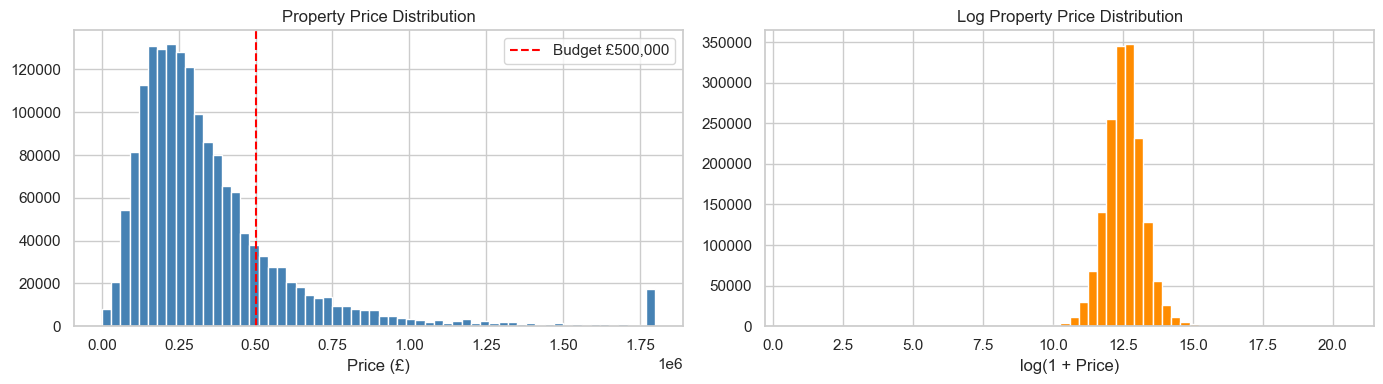

82.6% of all transactions are at or below the user budget


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw price histogram
axes[0].hist(tx_df['price'].clip(upper=tx_df['price'].quantile(0.99)),
             bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(USER_BUDGET, color='red', linestyle='--', label=f'Budget £{USER_BUDGET:,.0f}')
axes[0].set_title('Property Price Distribution')
axes[0].set_xlabel('Price (£)')
axes[0].legend()

# Log-scale
axes[1].hist(np.log1p(tx_df['price']), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Log Property Price Distribution')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

pct_affordable = (tx_df['price'] <= USER_BUDGET).mean()
print(f'{pct_affordable:.1%} of all transactions are at or below the user budget')

## 4 · Area-Level Aggregation Preview

In [ ]:
area_df = aggregate_to_area(tx_df)
# save this for later use in feature engineering
area_df.to_csv('../data/area_data.csv', index=False)
area_df.head(10)

,area,median_price,price_25th,price_75th,mean_price,price_std,num_listings
0,AL1,535000.0,365000.0,793125.0,699037.852124,1.067245e+06,1224
1,AL10,350000.0,262000.0,447500.0,457211.600000,1.505529e+06,705
2,AL2,540000.0,380000.0,695000.0,560197.048465,2.467188e+05,619
3,AL3,615500.0,446875.0,835000.0,694480.088083,4.067490e+05,772
4,AL4,625000.0,427500.0,860000.0,710099.899281,6.912576e+05,695
5,AL5,765000.0,515000.0,1200000.0,950206.355191,8.590852e+05,915
6,AL6,700000.0,518500.0,898750.0,780774.228477,4.186079e+05,302
7,AL7,395000.0,272250.0,470000.0,422672.369269,5.020036e+05,807
8,AL8,485000.0,369000.0,702750.0,554529.315113,2.905855e+05,311
9,AL9,560000.0,382500.0,897500.0,776765.813765,7.366385e+05,247


In [8]:
print(f'Number of distinct areas: {len(area_df)}')
area_df[['median_price', 'price_25th', 'price_75th', 'num_listings']].describe()

Number of distinct areas: 2307


,median_price,price_25th,price_75th,num_listings
count,2.307000e+03,2.307000e+03,2.307000e+03,2307.000000
mean,4.365749e+05,3.174646e+05,6.471813e+05,726.215865
std,1.463183e+06,1.311037e+06,2.001788e+06,484.582203
min,5.000000e+04,3.600000e+04,8.599900e+04,1.000000
25%,2.150000e+05,1.600000e+05,2.866000e+05,360.000000
50%,2.900000e+05,2.214600e+05,3.900000e+05,677.000000
75%,4.077500e+05,3.016875e+05,5.502500e+05,1003.500000
max,4.480000e+07,4.480000e+07,4.480000e+07,3561.000000


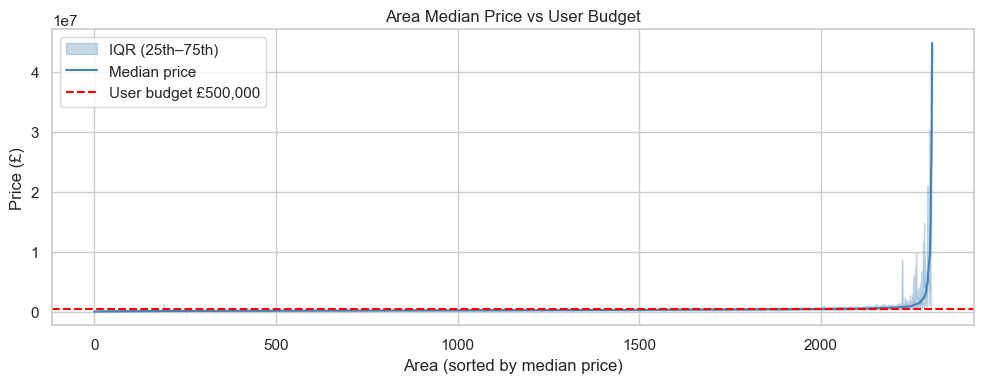

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
area_df_sorted = area_df.sort_values('median_price')

ax.fill_between(
    range(len(area_df_sorted)),
    area_df_sorted['price_25th'],
    area_df_sorted['price_75th'],
    alpha=0.3, color='steelblue', label='IQR (25th–75th)'
)
ax.plot(range(len(area_df_sorted)), area_df_sorted['median_price'],
        color='steelblue', label='Median price')
ax.axhline(USER_BUDGET, color='red', linestyle='--', label=f'User budget £{USER_BUDGET:,.0f}')
ax.set_xlabel('Area (sorted by median price)')
ax.set_ylabel('Price (£)')
ax.set_title('Area Median Price vs User Budget')
ax.legend()
plt.tight_layout()
plt.show()

## 5 · Affordability Baseline (raw)

In [10]:
area_df['affordable'] = (USER_BUDGET >= area_df['median_price']).astype(int)

counts = area_df['affordable'].value_counts().rename({0: 'Not Affordable', 1: 'Affordable'})
print('Area-level class distribution:')
print(counts)
print(f'\nBaseline affordability rate: {area_df["affordable"].mean():.1%}')

Area-level class distribution:
affordable
Affordable        2008
Not Affordable     299
Name: count, dtype: int64

Baseline affordability rate: 87.0%


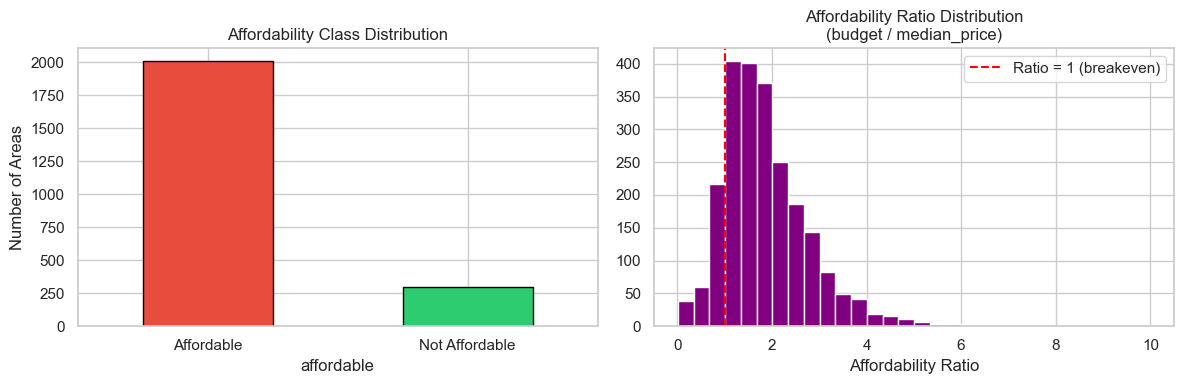

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class bar chart
counts.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Affordability Class Distribution')
axes[0].set_xticklabels(counts.index, rotation=0)
axes[0].set_ylabel('Number of Areas')

# Affordability ratio distribution
area_df['affordability_ratio'] = USER_BUDGET / area_df['median_price']
axes[1].hist(area_df['affordability_ratio'], bins=30, color='purple', edgecolor='white')
axes[1].axvline(1.0, color='red', linestyle='--', label='Ratio = 1 (breakeven)')
axes[1].set_title('Affordability Ratio Distribution\n(budget / median_price)')
axes[1].set_xlabel('Affordability Ratio')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6 · Geospatial Overview (optional)

In [12]:
if 'latitude' in area_df.columns and 'longitude' in area_df.columns:
    fig, ax = plt.subplots(figsize=(8, 7))
    sc = ax.scatter(
        area_df['longitude'], area_df['latitude'],
        c=area_df['median_price'], cmap='YlOrRd', s=30, alpha=0.7
    )
    plt.colorbar(sc, ax=ax, label='Median Price (£)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Median Price by Location')
    plt.tight_layout()
    plt.show()
else:
    print('No geospatial columns found – skipping map.')

No geospatial columns found – skipping map.


## 7 · Key Takeaways

_Update after running:_

- **Dataset:** N transactions across M areas
- **Price range:** £… – £… (median £…)
- **Affordability rate:** % of areas where budget ≥ median price
- **Class balance:** roughly balanced / imbalanced?
- **Outliers:** any extreme prices to consider?
- **Next step:** → `02_feature_engineering.ipynb`

area_df_sorted.head()

In [15]:
area_df.to_csv('../data/area_data.csv', index=False)